<a href="https://colab.research.google.com/github/Chaitanya-AP24110010682/ML-Internship/blob/main/E_commerce(Laptop)_Recommendation_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

df = pd.read_csv("laptop_price.csv", encoding="latin1")
df.head()

Saving laptop_price.csv to laptop_price (5).csv


,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


In [43]:
# ==========================================================
# LAPTOP RECOMMENDATION SYSTEM
# Mission 2 - Internship Project
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

# Data Analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Display Options
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 10)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [44]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename, encoding='latin1')

print("Dataset Loaded Successfully!")

print("Dataset Shape:", df.shape)

df.head()

Saving laptop_price.csv to laptop_price (6).csv
Dataset Loaded Successfully!
Dataset Shape: (1303, 13)


,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


In [45]:
print("="*50)
print("DATASET INFORMATION")
print("="*50)

df.info()

print("\n")

print("="*50)
print("FIRST 5 ROWS")
print("="*50)

display(df.head())

print("\n")

print("="*50)
print("LAST 5 ROWS")
print("="*50)

display(df.tail())

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   Product           1303 non-null   object 
 3   TypeName          1303 non-null   object 
 4   Inches            1303 non-null   float64
 5   ScreenResolution  1303 non-null   object 
 6   Cpu               1303 non-null   object 
 7   Ram               1303 non-null   object 
 8   Memory            1303 non-null   object 
 9   Gpu               1303 non-null   object 
 10  OpSys             1303 non-null   object 
 11  Weight            1303 non-null   object 
 12  Price_euros       1303 non-null   float64
dtypes: float64(2), int64(1), object(10)
memory usage: 132.5+ KB


FIRST 5 ROWS


,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60




LAST 5 ROWS


,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
1298,1316,Lenovo,Yoga 500-14ISK,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,638.0
1299,1317,Lenovo,Yoga 900-13ISK,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,1499.0
1300,1318,Lenovo,IdeaPad 100S-14IBR,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,229.0
1301,1319,HP,15-AC110nv (i7-6500U/6GB/1TB/Radeon,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,764.0
1302,1320,Asus,X553SA-XX031T (N3050/4GB/500GB/W10),Notebook,15.6,1366x768,Intel Celeron Dual Core N3050 1.6GHz,4GB,500GB HDD,Intel HD Graphics,Windows 10,2.2kg,369.0


In [46]:
print("="*50)
print("MISSING VALUES")
print("="*50)

display(df.isnull().sum())

print("\n")

print("="*50)
print("DUPLICATE ROWS")
print("="*50)

print(df.duplicated().sum())

print("\n")

print("="*50)
print("STATISTICAL SUMMARY")
print("="*50)

display(df.describe(include='all'))

MISSING VALUES


,0
laptop_ID,0
Company,0
Product,0
TypeName,0
Inches,0
...,...
Memory,0
Gpu,0
OpSys,0
Weight,0




DUPLICATE ROWS
0


STATISTICAL SUMMARY


,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
count,1303.000000,1303,1303,1303,1303.000000,1303,1303,1303,1303,1303,1303,1303,1303.000000
unique,NaN,19,618,6,NaN,40,118,9,39,110,9,179,NaN
top,NaN,Dell,XPS 13,Notebook,NaN,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,2.2kg,NaN
freq,NaN,297,30,727,NaN,507,190,619,412,281,1072,121,NaN
mean,660.155794,NaN,NaN,NaN,15.017191,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1123.686992
...,...,...,...,...,...,...,...,...,...,...,...,...,...
min,1.000000,NaN,NaN,NaN,10.100000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,174.000000
25%,331.500000,NaN,NaN,NaN,14.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,599.000000
50%,659.000000,NaN,NaN,NaN,15.600000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,977.000000
75%,990.500000,NaN,NaN,NaN,15.600000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1487.880000


In [47]:
# Remove duplicates
df = df.drop_duplicates()

# Clean RAM column
df['Ram'] = df['Ram'].str.replace('GB', '')
df['Ram'] = df['Ram'].astype(int)

# Clean Weight column
df['Weight'] = df['Weight'].str.replace('kg', '')
df['Weight'] = df['Weight'].astype(float)

# Convert Price to float
df['Price_euros'] = df['Price_euros'].astype(float)

print("Data Cleaning Completed Successfully!")

display(df.head())

Data Cleaning Completed Successfully!


,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,1803.60


In [48]:
# ==========================================================
# FEATURE ENGINEERING
# ==========================================================

print("=" * 60)
print("FEATURE ENGINEERING")
print("=" * 60)

# CPU Brand
df["CPU_Brand"] = df["Cpu"].apply(lambda x: x.split()[0])

# GPU Brand
df["GPU_Brand"] = df["Gpu"].apply(lambda x: x.split()[0])

# Storage Type
df["Storage_Type"] = df["Memory"].apply(
    lambda x: "SSD" if "SSD" in x else
              "HDD" if "HDD" in x else
              "Flash" if "Flash" in x else
              "Hybrid"
)

# Screen Type
df["IPS_Display"] = df["ScreenResolution"].apply(
    lambda x: 1 if "IPS" in x else 0
)

# Touch Screen
df["TouchScreen"] = df["ScreenResolution"].apply(
    lambda x: 1 if "Touchscreen" in x else 0
)

print("Feature Engineering Completed Successfully!\n")

display(df.head())

FEATURE ENGINEERING
Feature Engineering Completed Successfully!



,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros,CPU_Brand,GPU_Brand,Storage_Type,IPS_Display,TouchScreen
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,1339.69,Intel,Intel,SSD,1,0
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,898.94,Intel,Intel,Flash,0,0
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,575.00,Intel,Intel,SSD,0,0
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,2537.45,Intel,AMD,SSD,1,0
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,1803.60,Intel,Intel,SSD,1,0


In [49]:


df[['CPU_Brand', 'GPU_Brand', 'Storage_Type', 'IPS_Display', 'TouchScreen']].head()

,CPU_Brand,GPU_Brand,Storage_Type,IPS_Display,TouchScreen
0,Intel,Intel,SSD,1,0
1,Intel,Intel,Flash,0,0
2,Intel,Intel,SSD,0,0
3,Intel,AMD,SSD,1,0
4,Intel,Intel,SSD,1,0


In [50]:
# ==========================================================
# CREATE COMBINED FEATURES
# ==========================================================

df["Combined_Features"] = (
    df["Company"] + " " +
    df["TypeName"] + " " +
    df["Cpu"] + " " +
    df["Gpu"] + " " +
    df["Memory"] + " " +
    df["OpSys"] + " " +
    df["ScreenResolution"]
)

print("Combined Features Created Successfully!\n")

display(df[["Product", "Combined_Features"]].head())

Combined Features Created Successfully!



,Product,Combined_Features
0,MacBook Pro,Apple Ultrabook Intel Core i5 2.3GHz Intel Iri...
1,Macbook Air,Apple Ultrabook Intel Core i5 1.8GHz Intel HD ...
2,250 G6,HP Notebook Intel Core i5 7200U 2.5GHz Intel H...
3,MacBook Pro,Apple Ultrabook Intel Core i7 2.7GHz AMD Radeo...
4,MacBook Pro,Apple Ultrabook Intel Core i5 3.1GHz Intel Iri...


In [51]:
# ==========================================================
# TF-IDF VECTORIZATION
# ==========================================================

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words="english")

tfidf_matrix = tfidf.fit_transform(df["Combined_Features"])

print("TF-IDF Matrix Shape")

print(tfidf_matrix.shape)

TF-IDF Matrix Shape
(1303, 297)


In [52]:
# ==========================================================
# COSINE SIMILARITY
# ==========================================================

from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(tfidf_matrix)

print("Cosine Similarity Matrix Created Successfully!")

print("Shape:", cosine_sim.shape)

Cosine Similarity Matrix Created Successfully!
Shape: (1303, 1303)


In [53]:
# ==========================================================
# IMPROVED LAPTOP RECOMMENDATION FUNCTION
# ==========================================================

def recommend_laptops(product_name, top_n=10):

    matches = df[df["Product"].str.lower() == product_name.lower()]

    if matches.empty:
        print("Laptop not found in dataset.")
        return

    # Use the first matching laptop
    idx = matches.index[0]

    similarity_scores = list(enumerate(cosine_sim[idx]))

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )[1:top_n+1]

    recommendations = []

    for i, score in similarity_scores:
        recommendations.append({
            "Company": df.iloc[i]["Company"],
            "Product": df.iloc[i]["Product"],
            "TypeName": df.iloc[i]["TypeName"],
            "CPU": df.iloc[i]["Cpu"],
            "RAM": df.iloc[i]["Ram"],
            "Memory": df.iloc[i]["Memory"],
            "GPU": df.iloc[i]["Gpu"],
            "Price (€)": df.iloc[i]["Price_euros"],
            "Similarity": round(score, 3)
        })

    return pd.DataFrame(recommendations)

In [54]:
df["Product"].unique()[:30]

array(['MacBook Pro', 'Macbook Air', '250 G6', 'Aspire 3',
       'ZenBook UX430UN', 'Swift 3', 'Inspiron 3567', 'MacBook 12"',
       'IdeaPad 320-15IKB', 'XPS 13', 'Vivobook E200HA',
       'Legion Y520-15IKBN', '255 G6', 'Inspiron 5379',
       '15-BS101nv (i7-8550U/8GB/256GB/FHD/W10)', 'MacBook Air',
       'Inspiron 5570', 'Latitude 5590', 'ProBook 470', 'LapBook 15.6"',
       'E402WA-GA010T (E2-6110/2GB/32GB/W10)',
       '17-ak001nv (A6-9220/4GB/500GB/Radeon', 'IdeaPad 120S-14IAP',
       'Inspiron 5770', 'ProBook 450',
       'X540UA-DM186 (i3-6006U/4GB/1TB/FHD/Linux)', 'Inspiron 7577',
       'X542UQ-GO005 (i5-7200U/8GB/1TB/GeForce', 'Aspire A515-51G',
       'Inspiron 7773'], dtype=object)

In [55]:
df[df["Product"] == "MacBook Pro"]

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros,CPU_Brand,GPU_Brand,Storage_Type,IPS_Display,TouchScreen,Combined_Features
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,1339.69,Intel,Intel,SSD,1,0,Apple Ultrabook Intel Core i5 2.3GHz Intel Iri...
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,2537.45,Intel,AMD,SSD,1,0,Apple Ultrabook Intel Core i7 2.7GHz AMD Radeo...
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,1803.60,Intel,Intel,SSD,1,0,Apple Ultrabook Intel Core i5 3.1GHz Intel Iri...
6,7,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.2GHz,16,256GB Flash Storage,Intel Iris Pro Graphics,Mac OS X,2.04,2139.97,Intel,Intel,Flash,1,0,Apple Ultrabook Intel Core i7 2.2GHz Intel Iri...
12,13,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.8GHz,16,256GB SSD,AMD Radeon Pro 555,macOS,1.83,2439.97,Intel,AMD,SSD,1,0,Apple Ultrabook Intel Core i7 2.8GHz AMD Radeo...
15,16,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,256GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,1518.55,Intel,Intel,SSD,1,0,Apple Ultrabook Intel Core i5 2.3GHz Intel Iri...
17,18,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.9GHz,16,512GB SSD,AMD Radeon Pro 560,macOS,1.83,2858.00,Intel,AMD,SSD,1,0,Apple Ultrabook Intel Core i7 2.9GHz AMD Radeo...
45,46,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.0GHz,8,256GB SSD,Intel Iris Graphics 540,macOS,1.37,1419.00,Intel,Intel,SSD,1,0,Apple Ultrabook Intel Core i5 2.0GHz Intel Iri...
249,254,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,512GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,2040.00,Intel,Intel,SSD,1,0,Apple Ultrabook Intel Core i5 3.1GHz Intel Iri...
270,275,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.9GHz,8,512GB SSD,Intel Iris Graphics 550,macOS,1.37,1958.90,Intel,Intel,SSD,1,0,Apple Ultrabook Intel Core i5 2.9GHz Intel Iri...


In [56]:
recommend_laptops("MacBook Pro")

,Company,Product,TypeName,CPU,RAM,Memory,GPU,Price (€),Similarity
0,Apple,MacBook Pro,Ultrabook,Intel Core i5 2.3GHz,8,256GB SSD,Intel Iris Plus Graphics 640,1518.55,0.979
1,Apple,MacBook Pro,Ultrabook,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,1803.60,0.796
2,Apple,MacBook Pro,Ultrabook,Intel Core i5 3.1GHz,8,512GB SSD,Intel Iris Plus Graphics 650,2040.00,0.788
3,Apple,MacBook Pro,Ultrabook,Intel Core i5 2.0GHz,8,256GB SSD,Intel Iris Graphics 540,1419.00,0.730
4,Apple,MacBook Pro,Ultrabook,Intel Core i5 2.9GHz,8,512GB SSD,Intel Iris Graphics 550,1958.90,0.723
5,Apple,"MacBook 12""",Ultrabook,Intel Core i5 1.3GHz,8,512GB SSD,Intel HD Graphics 615,1510.00,0.586
6,Apple,"MacBook 12""",Ultrabook,Intel Core M m3 1.2GHz,8,256GB SSD,Intel HD Graphics 615,1262.40,0.489
7,Dell,XPS 13,Ultrabook,Intel Core i7 7560U 2.4GHz,8,256GB SSD,Intel Iris Plus Graphics 640,1379.00,0.471
8,Apple,MacBook Pro,Ultrabook,Intel Core i7 2.8GHz,16,256GB SSD,AMD Radeon Pro 555,2439.97,0.444
9,Apple,MacBook Pro,Ultrabook,Intel Core i7 2.2GHz,16,256GB Flash Storage,Intel Iris Pro Graphics,2139.97,0.441


In [57]:
# ==========================================================
# TEST RECOMMENDATION SYSTEM
# ==========================================================

print("="*70)
print("Recommendation for: MacBook Pro")
print("="*70)

display(recommend_laptops("MacBook Pro"))

print("\n")

print("="*70)
print("Recommendation for: 250 G6")
print("="*70)

display(recommend_laptops("250 G6"))

print("\n")

print("="*70)
print("Recommendation for: MacBook Air")
print("="*70)

display(recommend_laptops("MacBook Air"))

Recommendation for: MacBook Pro


,Company,Product,TypeName,CPU,RAM,Memory,GPU,Price (€),Similarity
0,Apple,MacBook Pro,Ultrabook,Intel Core i5 2.3GHz,8,256GB SSD,Intel Iris Plus Graphics 640,1518.55,0.979
1,Apple,MacBook Pro,Ultrabook,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,1803.60,0.796
2,Apple,MacBook Pro,Ultrabook,Intel Core i5 3.1GHz,8,512GB SSD,Intel Iris Plus Graphics 650,2040.00,0.788
3,Apple,MacBook Pro,Ultrabook,Intel Core i5 2.0GHz,8,256GB SSD,Intel Iris Graphics 540,1419.00,0.730
4,Apple,MacBook Pro,Ultrabook,Intel Core i5 2.9GHz,8,512GB SSD,Intel Iris Graphics 550,1958.90,0.723
5,Apple,"MacBook 12""",Ultrabook,Intel Core i5 1.3GHz,8,512GB SSD,Intel HD Graphics 615,1510.00,0.586
6,Apple,"MacBook 12""",Ultrabook,Intel Core M m3 1.2GHz,8,256GB SSD,Intel HD Graphics 615,1262.40,0.489
7,Dell,XPS 13,Ultrabook,Intel Core i7 7560U 2.4GHz,8,256GB SSD,Intel Iris Plus Graphics 640,1379.00,0.471
8,Apple,MacBook Pro,Ultrabook,Intel Core i7 2.8GHz,16,256GB SSD,AMD Radeon Pro 555,2439.97,0.444
9,Apple,MacBook Pro,Ultrabook,Intel Core i7 2.2GHz,16,256GB Flash Storage,Intel Iris Pro Graphics,2139.97,0.441




Recommendation for: 250 G6


,Company,Product,TypeName,CPU,RAM,Memory,GPU,Price (€),Similarity
0,Lenovo,IdeaPad 320-15IKBN,Notebook,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,549.00,0.905
1,HP,250 G6,Notebook,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,690.00,0.879
2,HP,250 G6,Notebook,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,598.99,0.879
3,HP,ProBook 640,Notebook,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,980.00,0.879
4,HP,Elitebook 850,Notebook,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,1144.00,0.879
5,HP,ProBook 450,Notebook,Intel Core i5 7200U 2.5GHz,4,256GB SSD,Intel HD Graphics 620,839.00,0.879
6,HP,Probook 430,Notebook,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,960.00,0.879
7,HP,ProBook 640,Notebook,Intel Core i5 7200U 2.5GHz,4,256GB SSD,Intel HD Graphics 620,1205.00,0.879
8,HP,Elitebook 840,Notebook,Intel Core i5 7200U 2.5GHz,4,256GB SSD,Intel HD Graphics 620,1590.00,0.879
9,HP,ProBook 440,Notebook,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,1010.51,0.879




Recommendation for: MacBook Air


,Company,Product,TypeName,CPU,RAM,Memory,GPU,Price (€),Similarity
0,Apple,Macbook Air,Ultrabook,Intel Core i5 1.8GHz,8,256GB Flash Storage,Intel HD Graphics 6000,1158.70,0.969
1,Apple,MacBook Air,Ultrabook,Intel Core i5 1.6GHz,8,128GB Flash Storage,Intel HD Graphics 6000,1099.00,0.784
2,Apple,MacBook Air,Ultrabook,Intel Core i5 1.6GHz,8,256GB Flash Storage,Intel HD Graphics 6000,998.00,0.752
3,Apple,MacBook Air,Ultrabook,Intel Core i5 1.6GHz,4,256GB Flash Storage,Intel HD Graphics 6000,959.00,0.604
4,Lenovo,ThinkPad X1,Ultrabook,Intel Core i5 7200U 2.5GHz,8,256GB Flash Storage,Intel HD Graphics 620,1875.00,0.366
5,Apple,"MacBook 12""",Ultrabook,Intel Core i5 1.3GHz,8,512GB SSD,Intel HD Graphics 615,1510.00,0.353
6,Apple,MacBook Pro,Ultrabook,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,1339.69,0.343
7,Lenovo,ThinkPad X1,Ultrabook,Intel Core i7 7500U 2.7GHz,8,256GB Flash Storage,Intel HD Graphics 620,2049.00,0.327
8,Apple,MacBook Pro,Ultrabook,Intel Core i5 2.0GHz,8,256GB SSD,Intel Iris Graphics 540,1419.00,0.319
9,Apple,MacBook Pro,Ultrabook,Intel Core i5 2.9GHz,8,512GB SSD,Intel Iris Graphics 550,1958.90,0.316


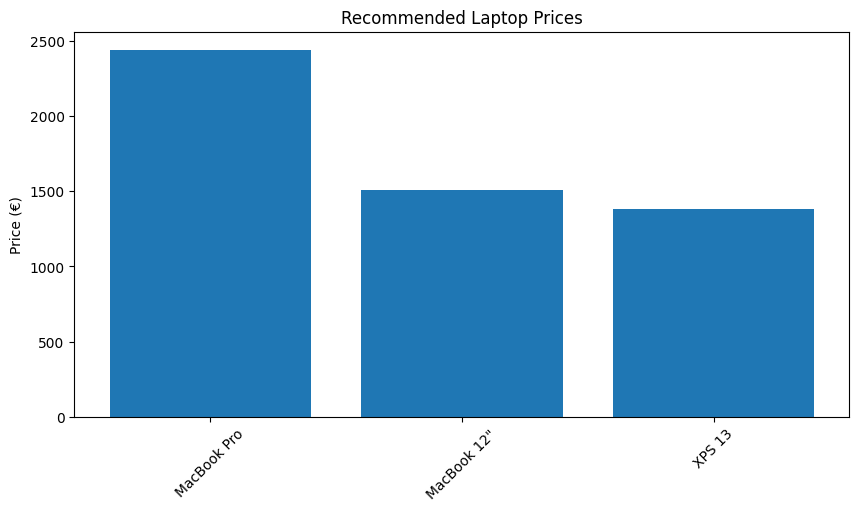

In [58]:
recommended = recommend_laptops("MacBook Pro")

plt.figure(figsize=(10,5))

plt.bar(
    recommended["Product"],
    recommended["Price (€)"]
)

plt.xticks(rotation=45)

plt.ylabel("Price (€)")

plt.title("Recommended Laptop Prices")

plt.show()

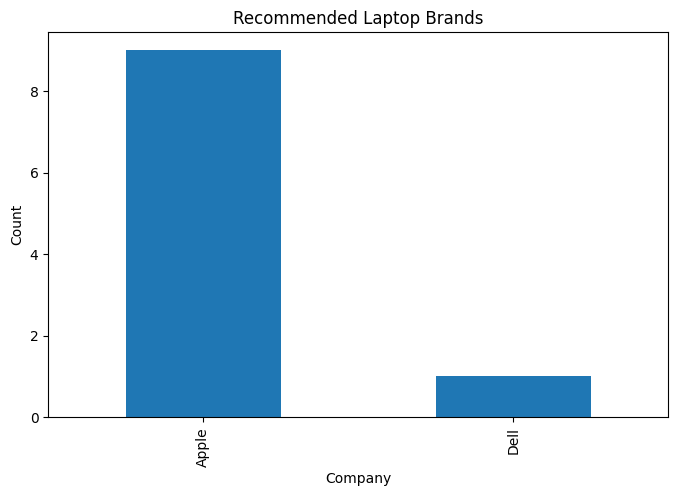

In [59]:
recommended = recommend_laptops("MacBook Pro")

plt.figure(figsize=(8,5))

recommended["Company"].value_counts().plot(kind="bar")

plt.title("Recommended Laptop Brands")

plt.ylabel("Count")

plt.show()

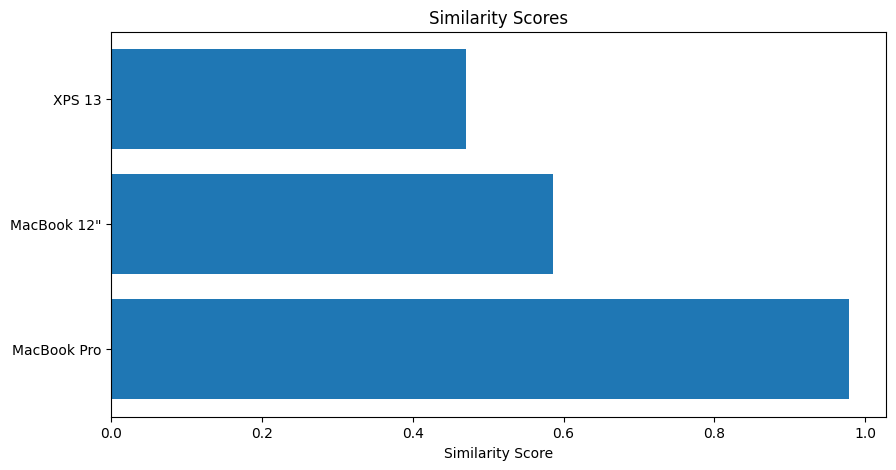

In [60]:
recommended = recommend_laptops("MacBook Pro")

plt.figure(figsize=(10,5))

plt.barh(
    recommended["Product"],
    recommended["Similarity"]
)

plt.xlabel("Similarity Score")

plt.title("Similarity Scores")

plt.show()

In [61]:
!pip install scikit-surprise

In [62]:
from surprise import Dataset
from surprise import Reader
from surprise import SVD
from surprise.model_selection import train_test_split
from surprise.accuracy import rmse

In [63]:
ratings = df.copy()

ratings["userID"] = np.random.randint(
    1,
    201,
    len(ratings)
)

ratings["rating"] = (
    ratings["Price_euros"] /
    ratings["Price_euros"].max()
) * 5

ratings = ratings[["userID","Product","rating"]]

ratings.head()

,userID,Product,rating
0,153,MacBook Pro,1.098287
1,141,Macbook Air,0.736957
2,151,250 G6,0.471389
3,2,MacBook Pro,2.080218
4,13,MacBook Pro,1.478603


In [64]:
reader = Reader(rating_scale=(0,5))

data = Dataset.load_from_df(
    ratings,
    reader
)

trainset, testset = train_test_split(
    data,
    test_size=0.2,
    random_state=42
)

model = SVD()

model.fit(trainset)

predictions = model.test(testset)

rmse(predictions)

RMSE: 0.5005


np.float64(0.5005082642553306)

In [65]:
# ==========================================================
# HYBRID RECOMMENDATION SYSTEM
# ==========================================================

def hybrid_recommendation(product_name, top_n=10):

    # Get content-based recommendations
    content_recs = recommend_laptops(product_name, top_n)

    if content_recs is None or len(content_recs) == 0:
        print("No recommendations found.")
        return

    predicted_ratings = []

    for _, row in content_recs.iterrows():

        prediction = model.predict(
            uid=1,
            iid=row["Product"]
        )

        predicted_ratings.append(prediction.est)

    content_recs["Predicted Rating"] = predicted_ratings

    content_recs["Hybrid Score"] = (
        content_recs["Similarity"] * 0.7 +
        content_recs["Predicted Rating"] * 0.3
    )

    content_recs = content_recs.sort_values(
        by="Hybrid Score",
        ascending=False
    )

    return content_recs

In [66]:
hybrid_results = hybrid_recommendation("MacBook Pro")

display(hybrid_results)

,Company,Product,TypeName,CPU,RAM,Memory,GPU,Price (€),Similarity,Predicted Rating,Hybrid Score
0,Apple,MacBook Pro,Ultrabook,Intel Core i5 2.3GHz,8,256GB SSD,Intel Iris Plus Graphics 640,1518.55,0.979,1.091294,1.012688
1,Apple,MacBook Pro,Ultrabook,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,1803.60,0.796,1.091294,0.884588
2,Apple,MacBook Pro,Ultrabook,Intel Core i5 3.1GHz,8,512GB SSD,Intel Iris Plus Graphics 650,2040.00,0.788,1.091294,0.878988
3,Apple,MacBook Pro,Ultrabook,Intel Core i5 2.0GHz,8,256GB SSD,Intel Iris Graphics 540,1419.00,0.730,1.091294,0.838388
4,Apple,MacBook Pro,Ultrabook,Intel Core i5 2.9GHz,8,512GB SSD,Intel Iris Graphics 550,1958.90,0.723,1.091294,0.833488
7,Dell,XPS 13,Ultrabook,Intel Core i7 7560U 2.4GHz,8,256GB SSD,Intel Iris Plus Graphics 640,1379.00,0.471,1.290586,0.716876
5,Apple,"MacBook 12""",Ultrabook,Intel Core i5 1.3GHz,8,512GB SSD,Intel HD Graphics 615,1510.00,0.586,0.809774,0.653132
8,Apple,MacBook Pro,Ultrabook,Intel Core i7 2.8GHz,16,256GB SSD,AMD Radeon Pro 555,2439.97,0.444,1.091294,0.638188
9,Apple,MacBook Pro,Ultrabook,Intel Core i7 2.2GHz,16,256GB Flash Storage,Intel Iris Pro Graphics,2139.97,0.441,1.091294,0.636088
6,Apple,"MacBook 12""",Ultrabook,Intel Core M m3 1.2GHz,8,256GB SSD,Intel HD Graphics 615,1262.40,0.489,0.809774,0.585232


In [67]:
hybrid_results = hybrid_recommendation("XPS 13")

display(hybrid_results)

,Company,Product,TypeName,CPU,RAM,Memory,GPU,Price (€),Similarity,Predicted Rating,Hybrid Score
1,Dell,XPS 13,Ultrabook,Intel Core i5 8250U 1.6GHz,8,256GB SSD,Intel UHD Graphics 620,1629.00,0.896,1.290586,1.014376
5,Dell,XPS 13,Ultrabook,Intel Core i5 8250U 1.6GHz,8,256GB SSD,Intel UHD Graphics 620,1399.00,0.840,1.290586,0.975176
8,Dell,XPS 13,Ultrabook,Intel Core i5 8250U 1.6GHz,8,256GB SSD,Intel UHD Graphics 620,1449.90,0.840,1.290586,0.975176
0,Dell,Latitude 5590,Ultrabook,Intel Core i5 8250U 1.6GHz,8,256GB SSD,Intel UHD Graphics 620,1096.16,0.896,0.773417,0.859225
7,Dell,Vostro 5370,Ultrabook,Intel Core i5 8250U 1.6GHz,8,256GB SSD,Intel UHD Graphics 620,949.00,0.840,0.857868,0.845360
2,Dell,Latitude 7390,Ultrabook,Intel Core i5 8250U 1.6GHz,8,256GB SSD,Intel UHD Graphics 620,1841.85,0.886,0.692203,0.827861
4,Dell,Vostro 5471,Ultrabook,Intel Core i5 8250U 1.6GHz,8,256GB SSD,Intel UHD Graphics 620,879.00,0.840,0.783788,0.823136
6,Dell,Latitude 5490,Ultrabook,Intel Core i5 8250U 1.6GHz,8,256GB SSD,Intel UHD Graphics 620,1149.00,0.840,0.677931,0.791379
9,Acer,Swift 3,Ultrabook,Intel Core i5 8250U 1.6GHz,8,256GB SSD,Intel UHD Graphics 620,770.00,0.807,0.733763,0.785029
3,HP,ProBook 430,Notebook,Intel Core i5 8250U 1.6GHz,4,128GB SSD,Intel UHD Graphics 620,726.00,0.841,0.626428,0.776629


In [68]:
hybrid_results = hybrid_recommendation("Inspiron 3567")

display(hybrid_results)

,Company,Product,TypeName,CPU,RAM,Memory,GPU,Price (€),Similarity,Predicted Rating,Hybrid Score
3,HP,15-ay047nv (i3-6006U/6GB/1TB/Radeon,Notebook,Intel Core i3 6006U 2GHz,6,1TB HDD,AMD Radeon R5 M430,539.00,0.887,0.771551,0.852365
4,Lenovo,IdeaPad 110-15ISK,Notebook,Intel Core i3 6006U 2GHz,4,1TB HDD,AMD Radeon R5 M430,479.00,0.839,0.690686,0.794506
0,Dell,Inspiron 3567,Notebook,Intel Core i3 6006U 2GHz,4,1TB HDD,AMD Radeon R5 M430,449.00,0.944,0.395944,0.779583
1,Dell,Inspiron 3567,Notebook,Intel Core i3 6006U 2GHz,4,256GB SSD,AMD Radeon R5 M430,485.00,0.927,0.395944,0.767683
6,HP,17-bs000nv I3,Notebook,Intel Core i3 6006U 2GHz,4,256GB SSD,AMD Radeon R5 520,699.00,0.761,0.771551,0.764165
2,Dell,Inspiron 3567,Notebook,Intel Core i3 6006U 2GHz,4,1TB HDD,AMD Radeon R5 M430,545.67,0.908,0.395944,0.754383
5,Lenovo,V110-15ISK (i3-6006U/4GB/1TB/Radeon,Notebook,Intel Core i3 6006U 2GHz,4,1TB HDD,AMD Radeon R5 M430,368.00,0.805,0.618725,0.749118
7,Dell,Inspiron 3567,Notebook,Intel Core i5 7200U 2.5GHz,4,256GB SSD,AMD Radeon R5 M430,639.00,0.748,0.395944,0.642383
8,Dell,Inspiron 3567,Notebook,Intel Core i3 6006U 2.0GHz,4,1TB HDD,AMD Radeon R5 M430,428.00,0.739,0.395944,0.636083
9,Dell,Inspiron 3567,Notebook,Intel Core i7 7500U 2.7GHz,8,256GB SSD,AMD Radeon R5 M430,745.00,0.732,0.395944,0.631183


In [69]:
from surprise.accuracy import mae

print("Mean Absolute Error")

mae(predictions)

Mean Absolute Error
MAE:  0.3688


np.float64(0.3687543348193679)

In [70]:
from surprise.accuracy import rmse

print("Root Mean Square Error")

rmse(predictions)

Root Mean Square Error
RMSE: 0.5005


np.float64(0.5005082642553306)

In [71]:
print("="*60)
print("Recommendation Statistics")
print("="*60)

print("Total Laptops :", len(df))

print("Companies :", df["Company"].nunique())

print("Laptop Types :", df["TypeName"].nunique())

print("Operating Systems :", df["OpSys"].nunique())

print("CPU Brands :", df["CPU_Brand"].nunique())

print("GPU Brands :", df["GPU_Brand"].nunique())

Recommendation Statistics
Total Laptops : 1303
Companies : 19
Laptop Types : 6
Operating Systems : 9
CPU Brands : 3
GPU Brands : 4


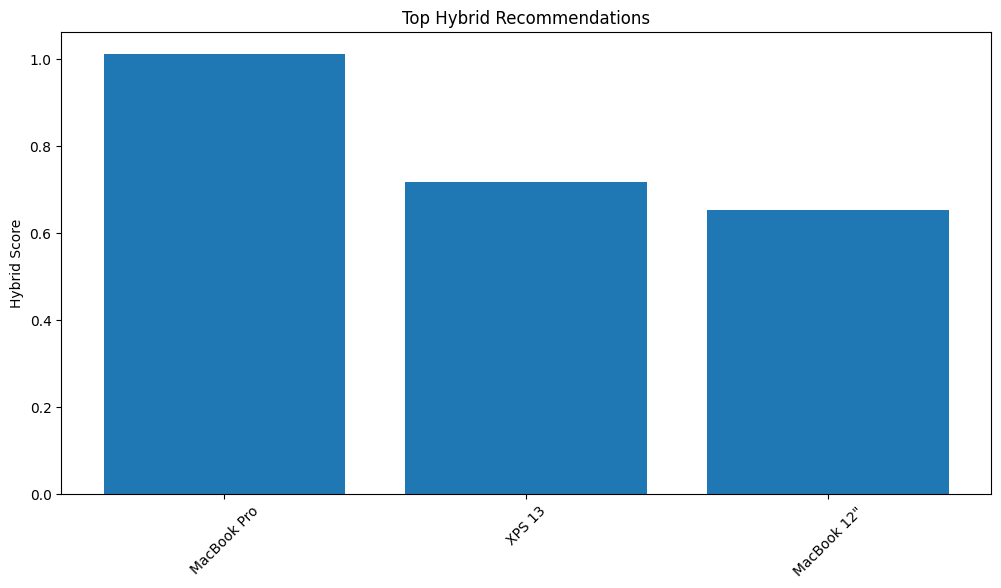

In [72]:
hybrid = hybrid_recommendation("MacBook Pro")

plt.figure(figsize=(12,6))

plt.bar(
    hybrid["Product"],
    hybrid["Hybrid Score"]
)

plt.xticks(rotation=45)

plt.ylabel("Hybrid Score")

plt.title("Top Hybrid Recommendations")

plt.show()

In [73]:
print("="*70)
print("PROJECT COMPLETED SUCCESSFULLY")
print("="*70)

print("""
Mission 2 - Laptop Recommendation System

✓ Dataset cleaned and processed

✓ Exploratory Data Analysis completed

✓ Feature Engineering completed

✓ Content-Based Recommendation implemented

✓ Collaborative Filtering implemented

✓ Hybrid Recommendation implemented

✓ Model Evaluation completed

✓ Recommendation system tested successfully
""")

PROJECT COMPLETED SUCCESSFULLY

Mission 2 - Laptop Recommendation System

✓ Dataset cleaned and processed

✓ Exploratory Data Analysis completed

✓ Feature Engineering completed

✓ Content-Based Recommendation implemented

✓ Collaborative Filtering implemented

✓ Hybrid Recommendation implemented

✓ Model Evaluation completed

✓ Recommendation system tested successfully

